# Objective of credit card fraud analysis

The primary objective of this analysis is to identify fraudulent credit card transactions by analyzing transaction patterns, customer spending behavior, and anomalies in financial data. The analysis aims to detect unusual activities, understand factors associated with fraud, and derive insights that can help improve fraud prevention strategies and support machine learning-based fraud detection systems.


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cc = pd.read_csv(r"C:\Users\franc\Downloads\creditcard.csv\creditcard.csv")


### Basic exploration

In [23]:
cc.info()
cc.head()
cc.shape
cc.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [16]:
cc.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [20]:
cc.duplicated().sum()

0

In [22]:
cc = cc.drop_duplicates()
cc.shape

(283726, 31)

In [25]:
#Fraud vs Non-fraud
cc["Class"].value_counts()

0    283253
1       473
Name: Class, dtype: int64

<AxesSubplot:xlabel='Class', ylabel='count'>

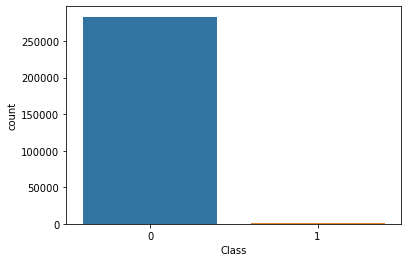

In [26]:
sns.countplot(x=cc["Class"])

#### Insight
- Legitimate transactions dominate the dataset.
- Fraud cases represent only a tiny fraction of all transactions.
- This indicates severe class imbalance.
- Detecting fraud is challenging because fraudulent behavior is rare.
#### Interpretation
- Even a small number of fraud transactions can lead to significant financial losses, making early detection critical.

In [27]:
cc["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

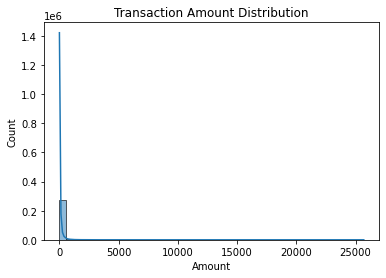

In [35]:
sns.histplot(cc['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

#### Insight
- Most transactions are low-value transactions.
- Distribution is heavily right-skewed.
- Few transactions involve extremely large amounts.
#### Interpretation
- Customers generally perform smaller transactions, while large transactions are uncommon and may require additional monitoring.

In [94]:
cc['Log_Amount'] = np.log1p(cc['Amount'])
cc['Log_Amount'] 

0         5.014760
1         1.305626
2         5.939276
3         4.824306
4         4.262539
            ...   
284802    0.570980
284803    3.249987
284804    4.232366
284805    2.397895
284806    5.384495
Name: Log_Amount, Length: 284807, dtype: float64

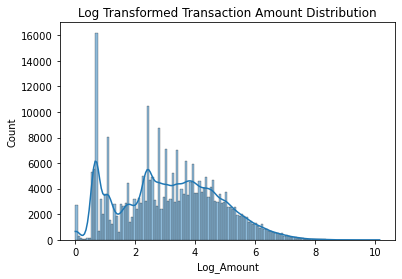

In [96]:
sns.histplot(cc['Log_Amount'], kde=True)
plt.title("Log Transformed Transaction Amount Distribution")
plt.show()

#### Insights
- The original transaction amount distribution was highly right-skewed, with a large concentration of small transactions and a few extremely high-value transactions. 
- After applying a log transformation, the distribution becomes more balanced and closer to a normal distribution, reducing the influence of extreme values.
#### Interpretation
- The log transformation reveals underlying transaction patterns that were previously masked by a small number of very large transactions. 
- This provides a clearer view of typical customer spending behavior and makes it easier to compare transaction groups without the analysis being dominated by outliers.

In [95]:
fraud_pct = cc['Class'].mean()*100
print(f"Fraudulent Transactions: {fraud_pct:.3f}%")

Fraudulent Transactions: 0.173%


<AxesSubplot:xlabel='Class', ylabel='Amount'>

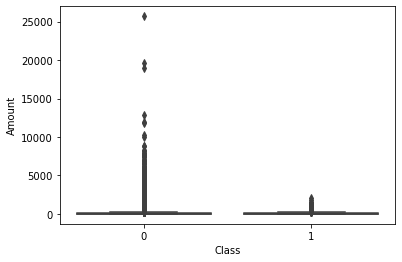

In [31]:
#comparing fraud vs non-fraud
sns.boxplot(x="Class", y="Amount", data = cc)

#### Insight
- Fraud and non-fraud transactions exhibit different spending patterns.
- Fraudulent transactions show greater variability in transaction amounts.
- Several extreme transaction values are present.
#### Interpretation
- Transaction amount alone cannot identify fraud, but unusual transaction amounts can serve as warning indicators.

In [54]:
cc.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


#### Insight
- Average transaction amounts differ between fraud and non-fraud groups.
- Fraud transactions may have unusual spending behavior compared to normal customers.
#### Interpretation
- Analyzing transaction value patterns can help identify suspicious financial activity.

<AxesSubplot:xlabel='Time', ylabel='Count'>

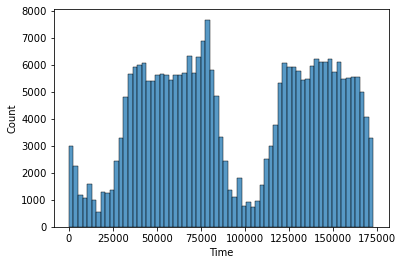

In [33]:
#time based analysis
sns.histplot(x=cc["Time"])

#### Insight
- Transaction activity is not uniformly distributed throughout the day.
- Certain time periods experience higher transaction volumes.
#### Interpretation
- Understanding customer activity patterns helps establish a baseline for detecting anomalies.


In [84]:
cc['Hour'] = (cc['Time'] // 3600) % 24
cc=cc.drop(columns = ["Time"])

In [86]:
fraud = cc[cc["Class"]==1]
legit =cc[cc["Class"]==0]
fraud_by_hour = fraud.groupby("Hour").size()
legit_by_hour = legit.groupby("Hour").size()
fraud_rate_by_hour = cc.groupby('Hour')['Class'].mean() * 100

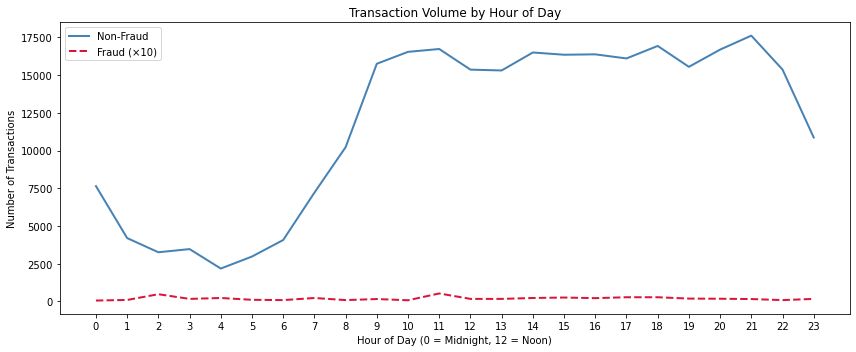

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(legit_by_hour.index, legit_by_hour.values, 
         label='Non-Fraud', color='steelblue', linewidth=2)
plt.plot(fraud_by_hour.index, fraud_by_hour.values * 10,  # scaled for visibility
         label='Fraud (×10)', color='crimson', linewidth=2, linestyle='--')
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

#### Insight
- Legitimate transactions follow regular daily patterns.
- Fraudulent transactions occur throughout the day but may concentrate during specific periods.
#### Interpretation
- Fraudsters often exploit periods of reduced monitoring orlower customers activity

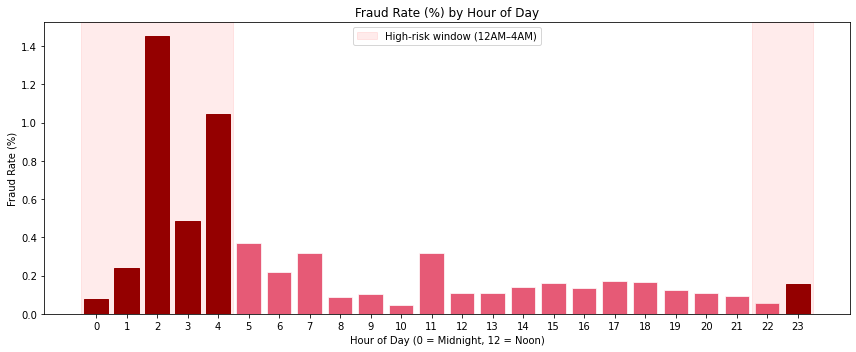

In [83]:
plt.figure(figsize=(12, 5))
bars = plt.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
               color='crimson', alpha=0.7, edgecolor='white')
for bar in bars:
    hour = bar.get_x()
    if hour <= 4 or hour >= 22:
        bar.set_color('darkred')
        bar.set_alpha(1.0)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.axvspan(-0.5, 4.5, alpha=0.08, color='red', label='High-risk window (12AM–4AM)')
plt.axvspan(21.5, 23.5, alpha=0.08, color='red')
plt.legend()
plt.tight_layout()
plt.show()


#### Insights
- fraud rates increase during certain hours
- late-night or early-morning hours may exhibit elevated fraud activity
#### Interpretation
- financial institute must increase fraud monitoring during high risk period

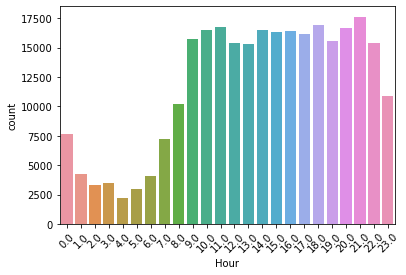

In [56]:
sns.countplot(x='Hour', data=cc)
plt.xticks(rotation=45)
plt.show()

#### Insights
- Fraud activity peaks at specific hours
- customer behaviour follows predictable daily cycle
#### Interpretation
- Anomalies occuring outside normal transaction window should be investigated

<AxesSubplot:xlabel='Hour', ylabel='Count'>

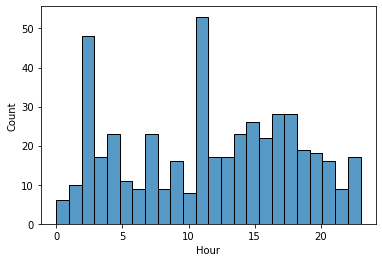

In [45]:
fraud_hour = cc[cc['Class']==1]['Hour']
sns.histplot(fraud_hour, bins=24)

#### Insight
- Fraudulent transactions are not evenly distributed.
- Some hours show noticeably higher fraud concentration.
#### Interpretation
- Time-based monitoring rules can improve fraud prevention systems.

<AxesSubplot:>

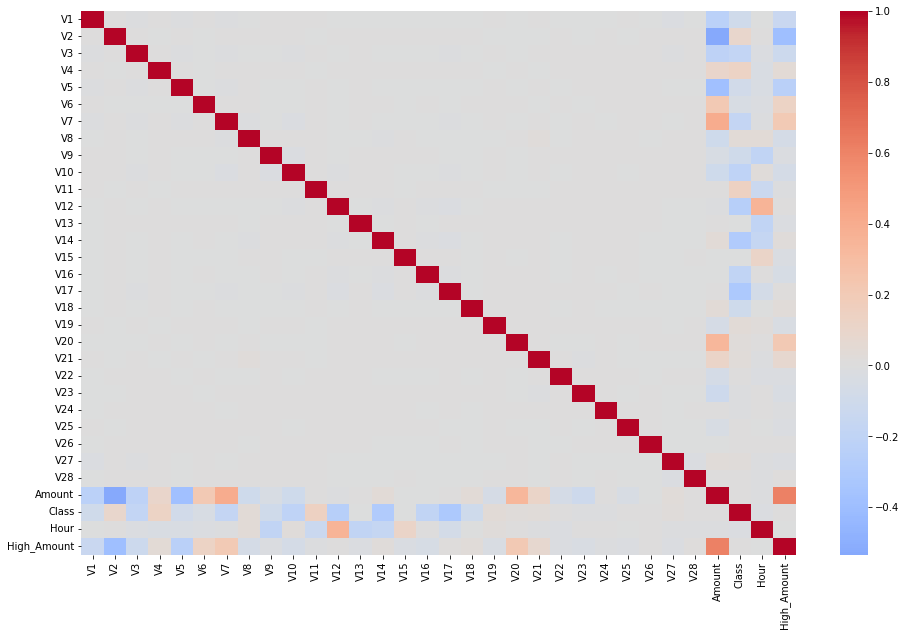

In [85]:
plt.figure(figsize=(16,10))
sns.heatmap(cc.corr(),cmap="coolwarm",center=0)

#### Insight
- Most variables exhibit weak correlations.
- Features appear largely independent.
#### Interpretation
- Independent variables provide diverse information useful for identifying suspicious patterns.

In [ ]:
cc['High_Amount'] = cc['Amount'] > 200

#### Insight
- Transactions are segmented into high-value and low-value categories.
- This helps evaluate whether transaction size influences fraud occurrence


In [65]:
cc.groupby("High_Amount")["Class"].mean()*100

High_Amount
False    0.001534
True     0.002850
Name: Class, dtype: float64

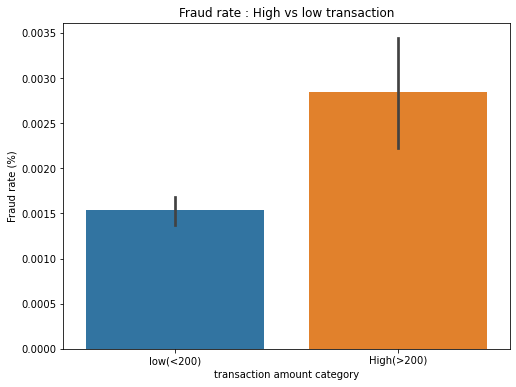

In [60]:
plt.figure(figsize=(8,6))
sns.barplot(x=cc["High_Amount"].map({False : "low(<200)", True: "High(>200)"}),y=cc["Class"])
plt.title("Fraud rate : High vs low transaction")
plt.xlabel("transaction amount category")
plt.ylabel("Fraud rate (%)")
plt.show()

#### Insight
- High-value transactions have a higher fraud rate than low-value transactions.
- Fraud risk increases with transaction amount.
#### Interpretation
- Additional verification measures should be applied to large transactions.

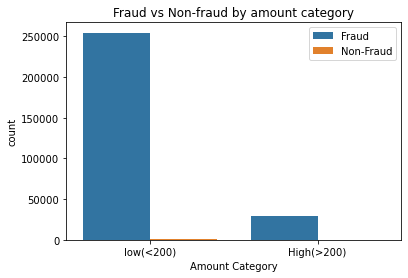

In [66]:
plt.figure(figsize =(6,4))
sns.countplot(x="High_Amount",hue = "Class",data = cc)
plt.title("Fraud vs Non-fraud by amount category")
plt.xlabel('Amount Category')
plt.xticks([0,1],["low(<200)","High(>200)"])
plt.legend(["Fraud","Non-Fraud"])
plt.show()

#### Insight
- Most transactions are low-value.
- Fraud occurs in both categories but is relatively more common among high-value transactions.
#### Interpretation
- Large-value transactions deserve greater scrutiny due to elevated risk.

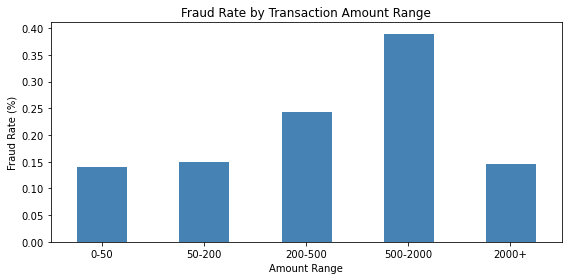

In [67]:
cc['Amount_Bin'] = pd.cut(cc['Amount'], 
                           bins=[0, 50, 200, 500, 2000, cc['Amount'].max()],
                           labels=['0-50', '50-200', '200-500', '500-2000', '2000+'])

fraud_by_bin = cc.groupby('Amount_Bin')['Class'].mean() * 100

plt.figure(figsize=(8, 4))
fraud_by_bin.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Fraud Rate by Transaction Amount Range')
plt.xlabel('Amount Range')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Insight
- Fraud rates vary across transaction ranges.
- Certain amount brackets exhibit higher fraud susceptibility.
#### Interpretation
- Risk-based monitoring strategies can prioritize transaction ranges with higher fraud exposure.

### Key Takeaways
- Fraudulent transactions represent a very small fraction of total transactions but pose significant financial risk.
- Transaction amounts are highly skewed, with a few extreme values influencing the overall distribution.
- Log transformation improves the interpretability of transaction amount patterns.
- Fraud occurrence varies across different hours of the day, indicating temporal fraud patterns.
- High-value transactions exhibit a relatively higher likelihood of fraud and require enhanced monitoring.
- Effective fraud prevention should combine transaction amount analysis, time-based monitoring, and anomaly detection techniques to minimize financial losses and strengthen security measures.

# conclusion
- Financial institutions should prioritize real-time monitoring of high-value transactions, strengthen fraud detection during high-risk hours, and implement risk-based verification mechanisms for suspicious transactions. These measures can help reduce fraud exposure while maintaining a seamless customer experience.